In [264]:
# Importamos lo datos a utilizar
import pandas as pd
import os

os.chdir("/Users/AlanHDLR/Desktop")
df = pd.read_csv("tempNY.csv")
df

,Year,Average,Unnamed: 2
0,1870,53.60,NaN
1,1871,51.13,NaN
2,1872,50.98,NaN
3,1873,50.98,NaN
4,1874,51.34,NaN
...,...,...,...
146,2016,57.18,NaN
147,2017,56.22,NaN
148,2018,55.88,NaN
149,2019,55.62,NaN


In [266]:
# Quitamos la columna vacia
df = df.drop("Unnamed: 2", axis = 1)
df

,Year,Average
0,1870,53.60
1,1871,51.13
2,1872,50.98
3,1873,50.98
4,1874,51.34
...,...,...
146,2016,57.18
147,2017,56.22
148,2018,55.88
149,2019,55.62


In [268]:
# Cambio de indice principal 
df.index = df["Year"]
df = df.drop("Year", axis = 1)
df

,Average
Year,
1870,53.60
1871,51.13
1872,50.98
1873,50.98
1874,51.34
...,...
2016,57.18
2017,56.22
2018,55.88


<Axes: xlabel='Year'>

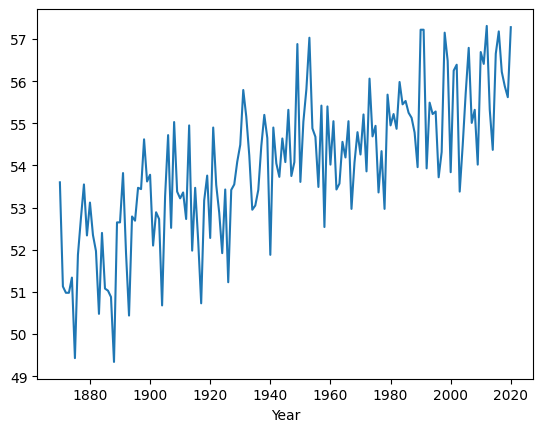

In [270]:
# Visualizamos la tendencia completa de los datos
df["Average"].plot()

In [272]:
# Calculamos el índice de corte
split_point = int(len(df) * 0.90)

# Dividimos la serie endatos de entrenamiento y prueba
train = df["Average"].iloc[:split_point]
test = df["Average"].iloc[split_point:]

print(f"Registros totales: {len(df)}")
print(f"Registros entrenamiento: {len(train)}")

Registros totales: 151
Registros entrenamiento: 135


In [274]:
# Obtenemos el valor p de Fuller para los datos de entrenamiento
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)
p_value = result[1]

print(f"Valor p de Dickey-Fuller (Original): {p_value:.4f}")

if p_value > 0.05:
    print("Los datos NO son estacionarios (No rechazamos H0).")
else:
    print("Los datos SON estacionarios (Rechazamos H0).")

Valor p de Dickey-Fuller (Original): 0.4220
Los datos NO son estacionarios (No rechazamos H0).


In [276]:
# Reiniciamos le index para ubicar Year en una columna normal
df = df.reset_index()

# Convertimos los valoresd ela columna year a formato "datetime"
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df = df.set_index('Year')

# Le damso el peridod de tiempo que vamos a manejar
df = df.asfreq('YS')

In [278]:
# Volvemos a dividir la serie
train = df["Average"].iloc[:split_point]
test = df["Average"].iloc[split_point:]

print(f"Registros totales: {len(df)}")
print(f"Registros entrenamiento: {len(train)}")
df

Registros totales: 151
Registros entrenamiento: 135


,Average
Year,
1870-01-01,53.60
1871-01-01,51.13
1872-01-01,50.98
1873-01-01,50.98
1874-01-01,51.34
...,...
2016-01-01,57.18
2017-01-01,56.22
2018-01-01,55.88


In [280]:
# Aplicamos la primera diferencia
train_diff = train.diff().dropna()

# Volvemos a probar
result_diff = adfuller(train_diff)
print(f"Valor p después de 1ra diferencia: {result_diff[1]:.4f}")

Valor p después de 1ra diferencia: 0.0000


In [282]:
# Aplicar primeras diferencias
df["temp_change"] = train_diff
df

,Average,temp_change
Year,,
1870-01-01,53.60,NaN
1871-01-01,51.13,-2.47
1872-01-01,50.98,-0.15
1873-01-01,50.98,0.00
1874-01-01,51.34,0.36
...,...,...
2016-01-01,57.18,NaN
2017-01-01,56.22,NaN
2018-01-01,55.88,NaN


In [284]:
# Importación del modulo para estimar un modelos ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Ajustar los datos a un modelo AR(1) e imprimirsi AIC:
mod_ar1 = ARIMA(df["temp_change"], order = (1,0,0))
res_ar1 = mod_ar1.fit()
print("El AIC para AR(1) con orden (1,0,0) es: ", res_ar1.aic)

El AIC para AR(1) con orden (1,0,0) es:  464.2789529854745


In [286]:
# Ajustar los datos a un modelo AR(1) e imprimirsi AIC:
mod_ar1 = ARIMA(df["temp_change"], order = (1,0,1))
res_ar1 = mod_ar1.fit()
print("El AIC para AR(1) con orden (1,0,1) es: ", res_ar1.aic)

El AIC para AR(1) con orden (1,0,1) es:  428.92693269195155


In [288]:
# Ajustar los datos a un modelo AR(1) e imprimirsi AIC:
mod_ar1 = ARIMA(df["temp_change"], order = (1,1,0))
res_ar1 = mod_ar1.fit()
print("El AIC para AR(1) con orden (1,1,0) es: ", res_ar1.aic)

El AIC para AR(1) con orden (1,1,0) es:  574.9685035908822


In [290]:
# Ajustar los datos a un modelo AR(1) e imprimirsi AIC:
mod_ar1 = ARIMA(df["temp_change"], order = (1,1,1))
res_ar1 = mod_ar1.fit()
print("El AIC para AR(1) con orden (1,1,1) es: ", res_ar1.aic)

El AIC para AR(1) con orden (1,1,1) es:  483.199876427622


In [292]:
# Ajustar los datos a un modelo AR(1) e imprimirsi AIC:
mod_ar1 = ARIMA(df["temp_change"], order = (2,0,1))
res_ar1 = mod_ar1.fit()
print("El AIC para AR(1) con orden (2,0,1) es: ", res_ar1.aic)

El AIC para AR(1) con orden (2,0,1) es:  430.2017104698697


In [294]:
# Ajustar los datos a un modelo AR(1) e imprimirsi AIC:
mod_ar1 = ARIMA(df["temp_change"], order = (2,1,1))
res_ar1 = mod_ar1.fit()
print("El AIC para AR(1) con orden (2,1,1) es: ", res_ar1.aic)

El AIC para AR(1) con orden (2,1,1) es:  474.98235743662406


In [296]:
# Ajustar los datos a un modelo AR(1) e imprimirsi AIC:
mod_ar1 = ARIMA(df["temp_change"], order = (1,1,2))
res_ar1 = mod_ar1.fit()
print("El AIC para AR(1) con orden (1,1,2) es: ", res_ar1.aic)

El AIC para AR(1) con orden (1,1,2) es:  452.98309701358613


In [298]:
# Visualizamos el promedio de los datos de prueba y entrenamiento para ver si tiene relación
print(train.mean())
print(test.mean())

53.76185185185185
55.986875


In [300]:
# Guardamos los valores optimos encontrados gracias al modelo de AIC
mod_optimo = ARIMA(train, order=(1, 0, 1)) 
res_optimo = mod_optimo.fit()

In [302]:
# Definimos cuántos pasos predecir 
n_pasos = len(test) 

# Obtenemos el pronóstico y los intervalos de confianza
forecast_obj = res_optimo.get_forecast(steps=n_pasos)
pronostico_puntual = forecast_obj.predicted_mean
intervalos = forecast_obj.conf_int()


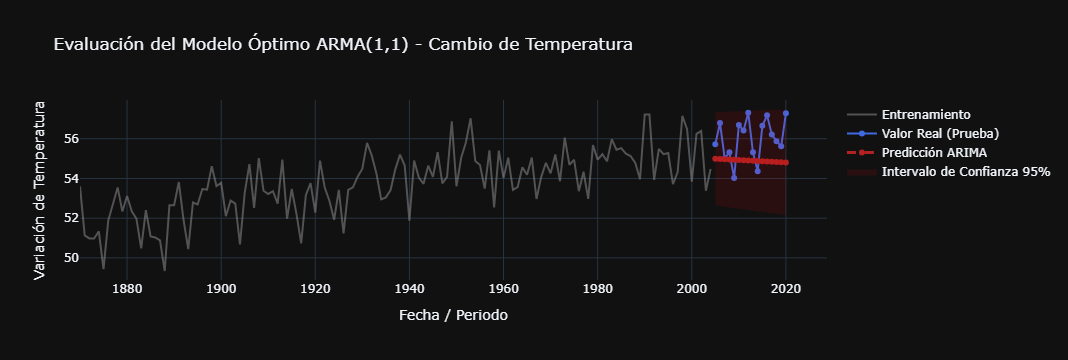

In [304]:
# CReamos la visualización
import plotly.graph_objects as go

fig_final = go.Figure()

# Serie de Entrenamiento
fig_final.add_trace(go.Scatter(x=train.index, y=train, name='Entrenamiento', line=dict(color='rgba(150, 150, 150, 0.5)')))

# Serie de Prueba
fig_final.add_trace(go.Scatter(x=test.index, y=test, name='Valor Real (Prueba)', line=dict(color='royalblue', width=2)))

# Predicción
fig_final.add_trace(go.Scatter(x=test.index, y=pronostico_puntual, name='Predicción ARIMA', line=dict(color='firebrick', dash='dash', width=3)))

# Intervalo de Confianza
# Creamos el área sombreada uniendo el límite superior con el inferior invertido
fig_final.add_trace(go.Scatter(x=list(test.index) + list(test.index[::-1]), 
                               y=list(intervalos.iloc[:, 1]) + list(intervalos.iloc[:, 0][::-1]), 
                               fill='toself', fillcolor='rgba(255, 0, 0, 0.1)', line=dict(color='rgba(255, 255, 255, 0)'), 
                               hoverinfo="skip", name='Intervalo de Confianza 95%'))

# Le damos el formato
fig_final.update_layout(
    title='Evaluación del Modelo Óptimo ARMA(1,1) - Cambio de Temperatura',
    xaxis_title='Fecha / Periodo',
    yaxis_title='Variación de Temperatura',
    template='plotly_dark',)

fig_final.show()

In [306]:
# Obtenemos los indicadores de error
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Calculamos las métricas
mae = mean_absolute_error(test, pronostico_puntual)
mse = mean_squared_error(test, pronostico_puntual)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, pronostico_puntual)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2%}")

MAE: 1.2650
RMSE: 1.4704
MAPE: 2.24%
